<a href="https://colab.research.google.com/github/maidana99edg/Codo_a_codo_Front_End/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Análisis Predictivo de Fuga de Clientes (Churn) ### Sector:
Fintech / Servicios **Estudiante:** Edgar Maidana **Objetivo:**
Identificar patrones de comportamiento que preceden a la cancelación de
servicios mediante Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de IA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
import pandas as pd

# Cargamos el archivo que acabas de subir a la carpeta de Colab
# Asegúrate de que el nombre entre comillas sea IGUAL al del archivo subido
df = pd.read_csv('/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Verificamos la carga
print("¡Archivo local cargado con éxito!")
df.head()

¡Archivo local cargado con éxito!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Revisamos la integridad de los datos y tipos de
variables

In [8]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Limpieza de Datos**

In [9]:
#TotalCharges a número
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#nuevos nulos con la mediana (para no perder datos)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

#Eliminamos CustomerID (no aporta al modelo)
df.drop('customerID', axis=1, inplace=True)

print("Limpieza técnica completada.")

Limpieza técnica completada.


### **Ingeniería de Características (Encoding)**

In [10]:
# Convertimos todas las palabras en columnas de 0 y 1
df_preparado = pd.get_dummies(df, drop_first=True)

# Mostramos cómo quedó la tabla
df_preparado.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


### **División de Datos (Entrenamiento y Prueba)**

In [11]:
# Definimos X (las características) y y (lo que queremos predecir: Churn_Yes)
X = df_preparado.drop('Churn_Yes', axis=1)
y = df_preparado['Churn_Yes']

# Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")

Datos de entrenamiento: 5634 muestras
Datos de prueba: 1409 muestras


### **Entrenamiento del Modelo (IA)**

In [12]:
# 1. Creacion el modelo
modelo_ia = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento (X_train, y_train)
modelo_ia.fit(X_train, y_train)

# 3. Realizar las predicciones con los datos que la IA NUNCA vio (X_test)
predicciones = modelo_ia.predict(X_test)

print("¡Entrenamiento completado!")

¡Entrenamiento completado!


### **Evaluación de Resultados**

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1036
        True       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



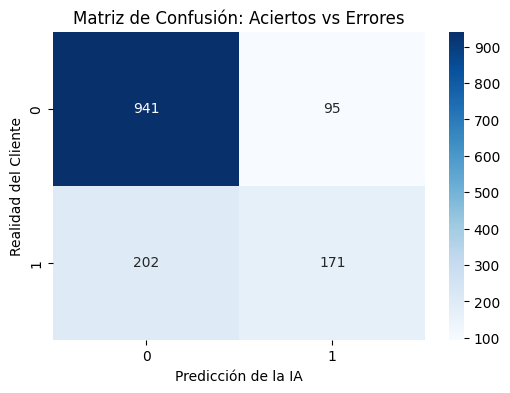

In [13]:
# Mostramos las métricas de éxito
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, predicciones))

# Graficamos la Matriz de Confusión para que sea más visual
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predicciones), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad del Cliente')
plt.title('Matriz de Confusión: Aciertos vs Errores')
plt.show()

### **Variables Importantes**

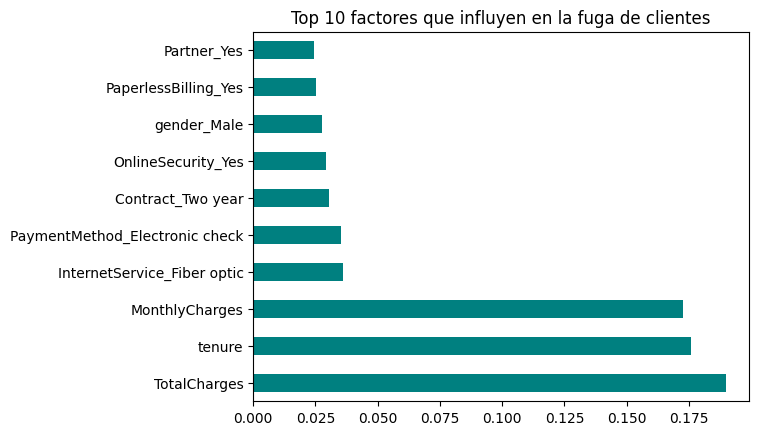

In [14]:
# Extraemos la importancia de las características
importancias = pd.Series(modelo_ia.feature_importances_, index=X.columns)
importancias.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 factores que influyen en la fuga de clientes')
plt.show()

### **Conclusiones del Modelo:**

1- El modelo identifica la fuga con las variables de facturación y antigüedad como ejes principales.

2- Se recomienda a la empresa revisar los planes de "Fibra Óptica", ya que aparecen como un factor relevante en la decisión de abandono.

3- Los clientes con mayor "tenure" (antigüedad) son más estables, lo que sugiere que las promociones deben enfocarse en los primeros meses de servicio.

In [15]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, predicciones)
print(f"La precisión final de mi IA es: {acc:.2%}")

La precisión final de mi IA es: 78.92%
